## EDA 

#### Imports & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign

print(df.shape)
print(df.head())

(569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0   

#### Basic Info

In [2]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nTarget values:", data.target_names)  # 0=malignant, 1=benign
print(df['target'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

#### Class Distribution Plot

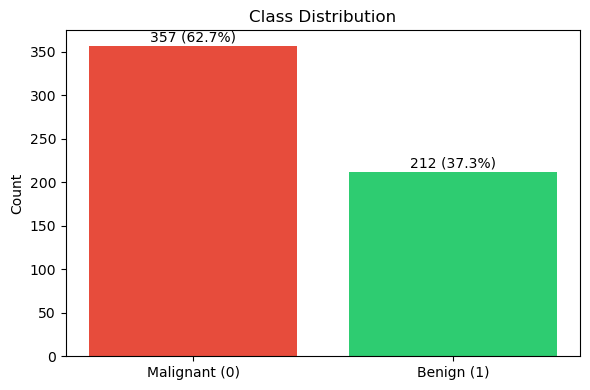

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['target'].value_counts()
ax.bar(['Malignant (0)', 'Benign (1)'], counts.values, color=['#e74c3c', '#2ecc71'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, f'{v} ({v/len(df)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#### Feature Correlations with Target

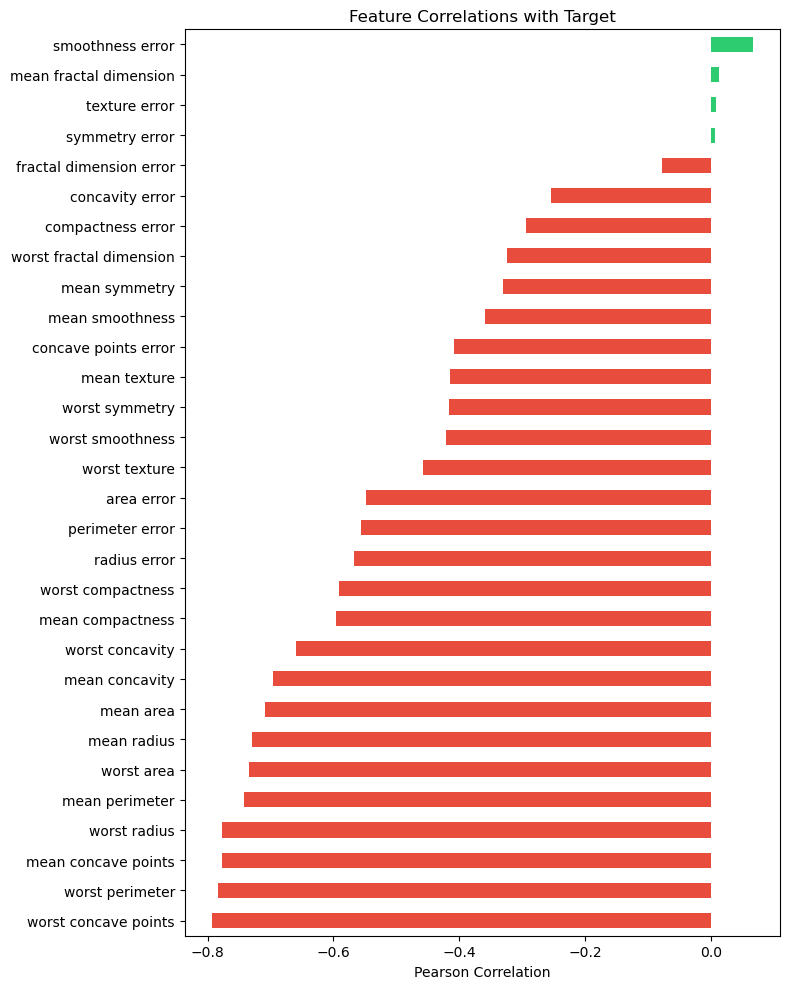

In [4]:
correlations = df.corr()['target'].drop('target').sort_values()
plt.figure(figsize=(8, 10))
correlations.plot(kind='barh', color=['#e74c3c' if x < 0 else '#2ecc71' for x in correlations])
plt.title('Feature Correlations with Target')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('results/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

#### Feature to feature Correlation Heatmap

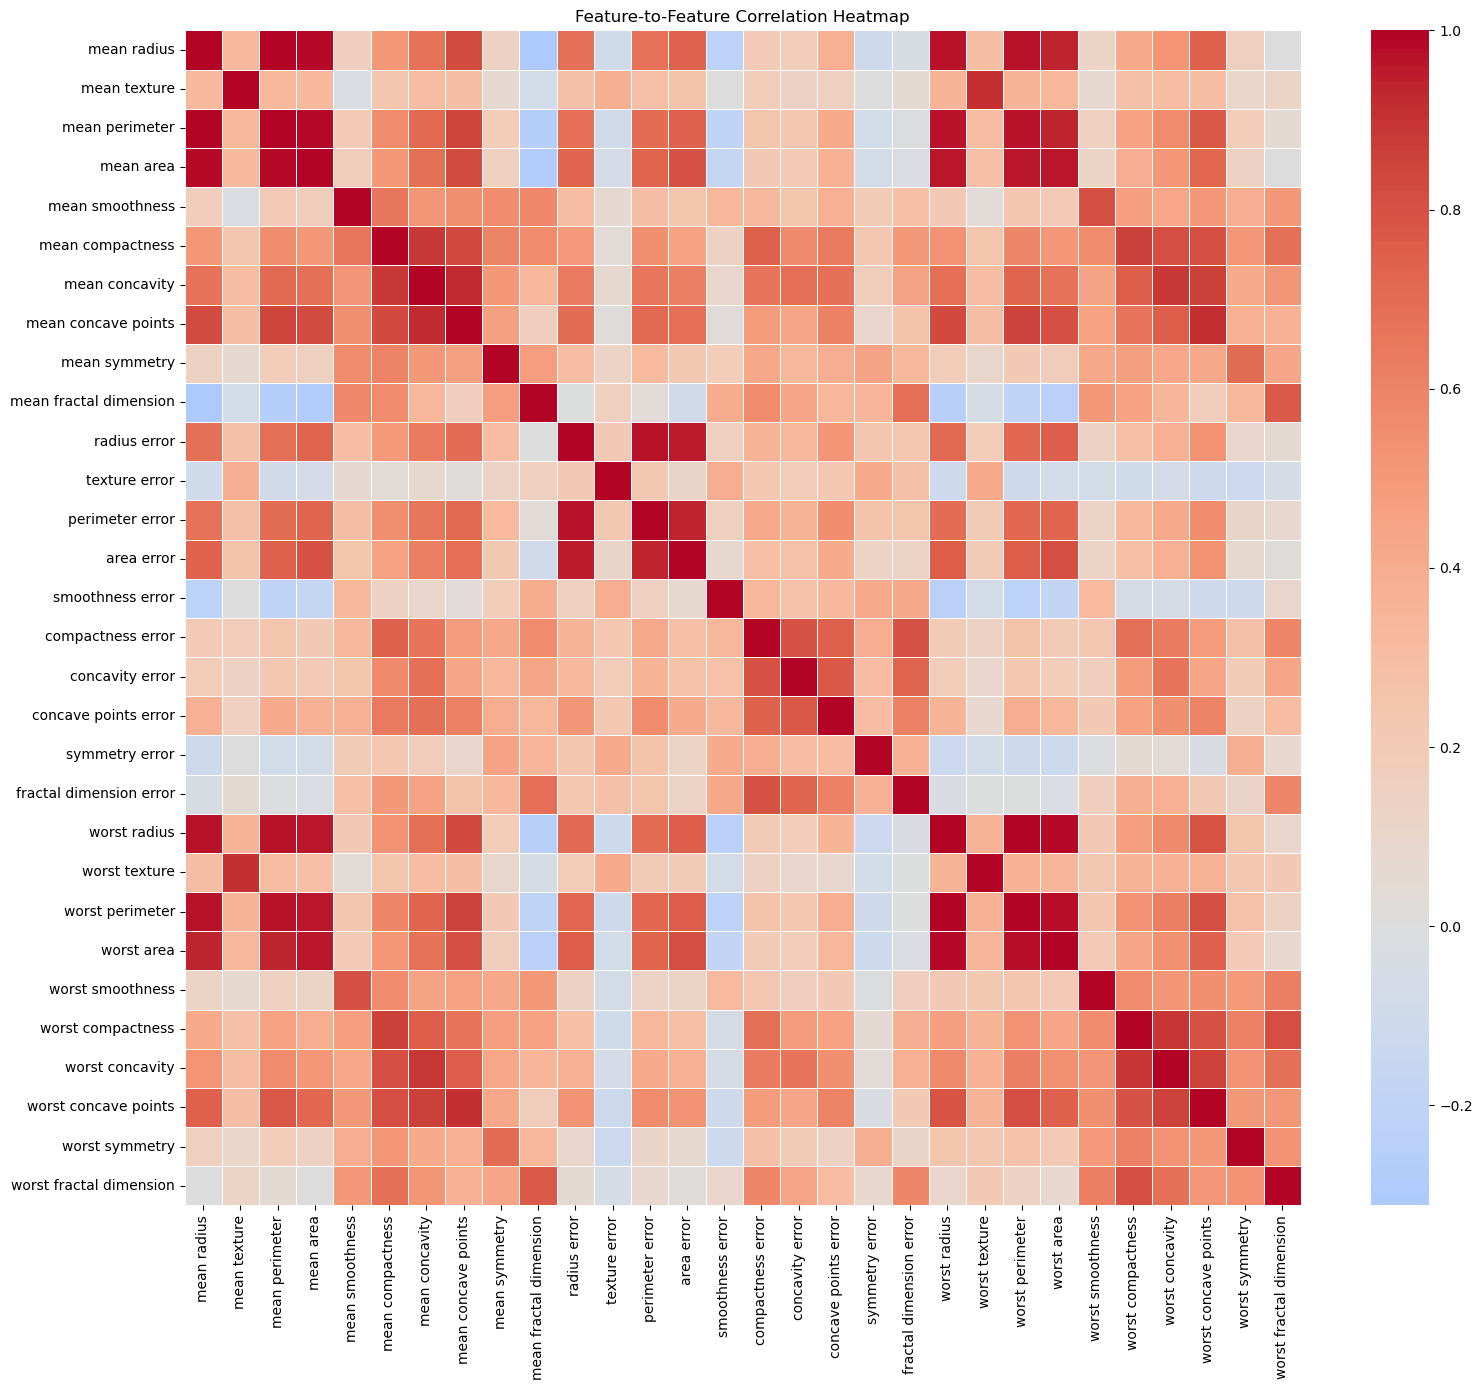

In [5]:
plt.figure(figsize=(16, 14))
sns.heatmap(df.drop('target', axis=1).corr(), cmap='coolwarm', center=0,
            linewidths=0.5, annot=False)
plt.title('Feature-to-Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('results/feature_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#### Key Insights

1. **Class imbalance & evaluation focus:**

The dataset shows a moderate class imbalance (malignant: 357, benign: 212). While not extreme, this can bias the model toward the majority class. In this context, false negatives are far more critical than overall accuracy, since misclassifying malignant cases as benign carries serious risk. Evaluation should prioritize recall/sensitivity over accuracy.

2. **Feature importance patterns:**

Predictive power is distributed across multiple feature groups, particularly tumor size and shape irregularity. Features such as worst concave points strongly correlate with malignancy, as they capture irregular and invasive growth patterns, while size-related features reflect uncontrolled cell proliferation.

3. **Multicollinearity and interpretability:**

Many features exhibit high correlation, leading to multicollinearity. While this does not significantly harm predictive performance in logistic regression, it makes model coefficients unstable and less reliable for interpretation. As a result, predictions remain trustworthy, but individual feature importance should be interpreted with caution.